# 🧠 TechMind — Motor de Búsqueda Semántica

Este notebook construye el componente de **recuperación de información** de TechMind: dado un texto, encuentra los documentos más similares dentro de la base de conocimiento.

**Arquitectura del proyecto (actualizada):**
- `/analizar_texto` → resuelto por Gemini (Maximiliano): categoría, dificultad y keywords.
- `/buscar_parecido` → resuelto en este notebook: vectorización TF-IDF + similitud de coseno sobre el corpus limpio de 1008 documentos.

El resultado se exporta como `.joblib` para que el equipo de Backend lo conecte a la API.

Paso 1: Imports simplificados

In [1]:
import re
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import joblib

sns.set_theme(style="whitegrid")
print("Entorno inicializado.")

Entorno inicializado.


Paso 2: Carga del corpus real

In [3]:
df = pd.read_csv("dataset_techmind_ready.csv")
print("Filas:", df.shape[0])
df.head()

Filas: 1008


,doc_id,titulo,source_type,texto,language,clean_length_chars,clean_length_words
0,56bc8ec1-4e0e-44f6-a787-3c1b441ba751,Contexto: Search for a text pattern,Tutorial_Codigo,Contexto: Search for a text pattern in multipl...,en,267,42
1,0cea7e84-7034-4fa6-b157-3fc062ce00da,Contexto: Profile code execution time: {code},Tutorial_Codigo,Contexto: Profile code execution time: {code} ...,fr,233,27
2,31c3ea14-d797-4065-a5fc-23e4ba0ef54e,Contexto: Send a weekly scheduled email,Tutorial_Codigo,Contexto: Send a weekly scheduled email with t...,en,491,49
3,8cd4c184-4fa0-4550-bbf5-37b7be6c2556,"In this paper, we consider the",Articulo_Academico,"In this paper, we consider the nonasymptotic s...",en,922,147
4,067195dc-34d2-4ea3-9d29-be40c123180e,Contexto: List all running Docker containers,Tutorial_Codigo,Contexto: List all running Docker containers C...,en,124,17


In [4]:
print(df.columns.tolist())
print(df.shape)

['doc_id', 'titulo', 'source_type', 'texto', 'language', 'clean_length_chars', 'clean_length_words']
(1008, 7)


Paso 3: EDA rápido

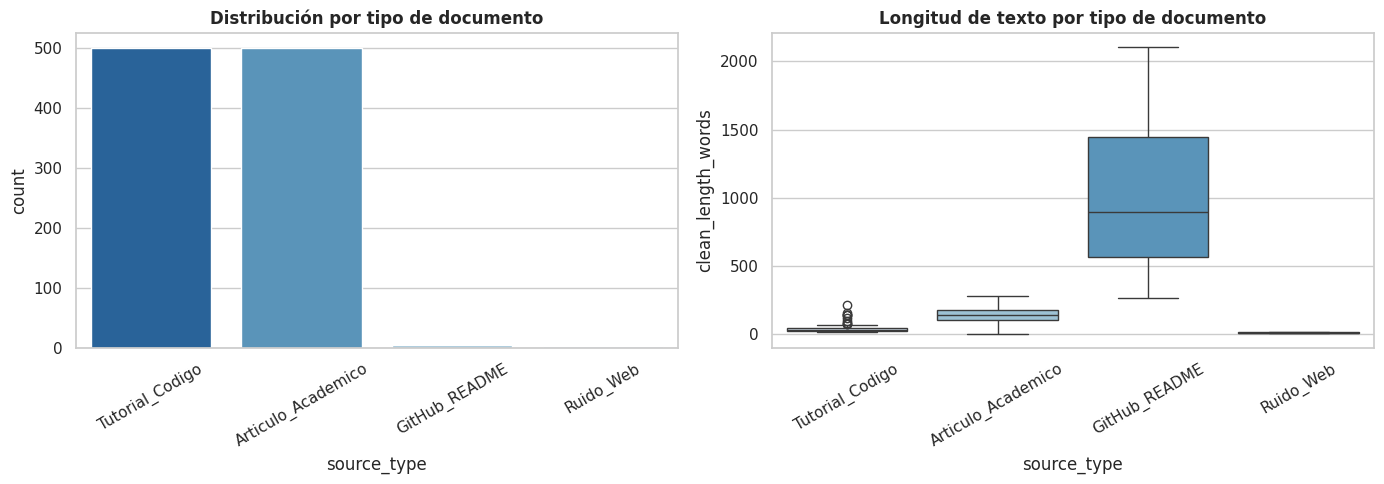

language
en    973
fr     23
es     10
ca      2
Name: count, dtype: int64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='source_type', hue='source_type', legend=False, palette='Blues_r', ax=axes[0])
axes[0].set_title('Distribución por tipo de documento', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='source_type', y='clean_length_words', hue='source_type', legend=False, palette='Blues', ax=axes[1])
axes[1].set_title('Longitud de texto por tipo de documento', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(df['language'].value_counts())

Paso 4: Limpieza ligera

In [11]:
def limpiar_texto_ligero(texto: str) -> str:
    if not isinstance(texto, str):
        return ""
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)
    texto = re.sub(r'<.*?>', '', texto)
    texto = re.sub(r'```.*?```', '', texto, flags=re.DOTALL)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Importante: reseteamos el índice para garantizar que la posición en el DataFrame
# coincida exactamente con la posición en la matriz de embeddings (fila i <-> embeddings[i])
df = df.reset_index(drop=True)
df['texto_para_embedding'] = df['texto'].apply(limpiar_texto_ligero)
df[['titulo', 'texto_para_embedding']].head(3)

,titulo,texto_para_embedding
0,Contexto: Search for a text pattern,Contexto: Search for a text pattern in multipl...
1,Contexto: Profile code execution time: {code},Contexto: Profile code execution time: {code} ...
2,Contexto: Send a weekly scheduled email,Contexto: Send a weekly scheduled email with t...


Paso 5: Generación de embeddings

In [12]:
!pip install -q sentence-transformers
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

embeddings = model.encode(
    df['texto_para_embedding'].tolist(),
    show_progress_bar=True,
    batch_size=32
)
print("Shape de embeddings:", embeddings.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Shape de embeddings: (1008, 384)


Paso 6a — Motor de búsqueda por texto libre

In [13]:
def buscar_por_texto(query_texto: str, top_n: int = 3, umbral: float = 0.3):
    vector_query = model.encode([query_texto])
    puntuaciones = cosine_similarity(vector_query, embeddings).flatten()
    indices = np.argsort(puntuaciones)[-top_n:][::-1]

    resultados = []
    for i in indices:
        if puntuaciones[i] > umbral:
            resultados.append({
                'doc_id': df.iloc[i]['doc_id'],
                'titulo': df.iloc[i]['titulo'],
                'source_type': df.iloc[i]['source_type'],
                'similitud_score': round(float(puntuaciones[i]), 3)
            })
    return resultados

Paso 6b — Motor de búsqueda por doc_id

In [14]:
def buscar_por_id(doc_id: str, top_n: int = 3, umbral: float = 0.3):
    # 1. Localizar la posición del documento de referencia
    coincidencias = df.index[df['doc_id'] == doc_id]
    if len(coincidencias) == 0:
        return {'error': f'doc_id no encontrado: {doc_id}'}
    indice_referencia = coincidencias[0]

    # 2. Reutilizamos el embedding ya calculado, sin volver a pasar por el modelo
    vector_referencia = embeddings[indice_referencia].reshape(1, -1)
    puntuaciones = cosine_similarity(vector_referencia, embeddings).flatten()

    # 3. Excluimos el propio documento del resultado (siempre tendría score 1.0 consigo mismo)
    puntuaciones[indice_referencia] = -1

    indices = np.argsort(puntuaciones)[-top_n:][::-1]
    resultados = []
    for i in indices:
        if puntuaciones[i] > umbral:
            resultados.append({
                'doc_id': df.iloc[i]['doc_id'],
                'titulo': df.iloc[i]['titulo'],
                'source_type': df.iloc[i]['source_type'],
                'similitud_score': round(float(puntuaciones[i]), 3)
            })
    return resultados

# Prueba: buscar documentos parecidos al primero del dataset
print(json.dumps(buscar_por_id(df.iloc[0]['doc_id']), indent=2, ensure_ascii=False))

[
  {
    "doc_id": "eae0cf72-8ef5-489a-b8de-f7ab48296625",
    "titulo": "Contexto: Search for word in files",
    "source_type": "Tutorial_Codigo",
    "similitud_score": 0.808
  },
  {
    "doc_id": "e39a3455-3058-4d7c-ab1c-8552b1372ceb",
    "titulo": "Contexto: List all text files in",
    "source_type": "Tutorial_Codigo",
    "similitud_score": 0.767
  },
  {
    "doc_id": "2a467f52-fda9-495a-bb4c-6b35db659652",
    "titulo": "Contexto: Search for a file named",
    "source_type": "Tutorial_Codigo",
    "similitud_score": 0.727
  }
]


Paso 7: buscar_parecido, la función que expone la API (detecta texto vs. ID automáticamente)

In [15]:
def es_doc_id_valido(entrada: str) -> bool:
    # los doc_id son UUIDs — un chequeo simple de formato basta para distinguirlos de texto libre
    return bool(re.fullmatch(r'[0-9a-fA-F-]{36}', entrada.strip()))

def buscar_parecido(entrada: str, top_n: int = 3) -> str:
    if es_doc_id_valido(entrada):
        resultados = buscar_por_id(entrada, top_n=top_n)
    else:
        resultados = buscar_por_texto(entrada, top_n=top_n)
    return json.dumps({"resultados_similares": resultados}, indent=2, ensure_ascii=False)

# Prueba 1: por texto en español (el caso que antes fallaba)
print(buscar_parecido("necesito automatizar el despliegue de contenedores en la nube"))

# Prueba 2: por doc_id
print(buscar_parecido(df.iloc[0]['doc_id']))

{
  "resultados_similares": [
    {
      "doc_id": "b8a4743c-b051-42d5-a862-0b78a5ab54e3",
      "titulo": "Point clouds are sets of points",
      "source_type": "Articulo_Academico",
      "similitud_score": 0.479
    },
    {
      "doc_id": "e61a3f4a-c0ed-4885-b423-cc4ef1b217ba",
      "titulo": "We describe a novel approach to",
      "source_type": "Articulo_Academico",
      "similitud_score": 0.412
    },
    {
      "doc_id": "be875b82-506c-4a42-8b52-77ef1c9bd816",
      "titulo": "We present a streaming model for",
      "source_type": "Articulo_Academico",
      "similitud_score": 0.406
    }
  ]
}
{
  "resultados_similares": [
    {
      "doc_id": "eae0cf72-8ef5-489a-b8de-f7ab48296625",
      "titulo": "Contexto: Search for word in files",
      "source_type": "Tutorial_Codigo",
      "similitud_score": 0.808
    },
    {
      "doc_id": "e39a3455-3058-4d7c-ab1c-8552b1372ceb",
      "titulo": "Contexto: List all text files in",
      "source_type": "Tutorial_Codigo",
    

Paso 8: Serialización (sin cambios respecto a la versión anterior)

In [16]:
artefacto_busqueda = {
    'embeddings': embeddings,
    'metadata_docs': df[['doc_id', 'titulo', 'source_type']],
    'model_name': 'paraphrase-multilingual-MiniLM-L12-v2'
}
joblib.dump(artefacto_busqueda, "techmind_busqueda_v2.joblib")
print("✔ techmind_busqueda_v2.joblib generado")

✔ techmind_busqueda_v2.joblib generado
